# In this notebook we explore the JaxGB templates

In [18]:
# ==================== Imports ====================
import os
import sys
import tempfile
from pathlib import Path
import corner
import healpy as hp
import eryn

# Eryn imports for transdimensional MCMC
from eryn.moves import MHMove, StretchMove
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.ensemble import EnsembleSampler
from eryn.state import State


import h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from segwo_utils import (InterpolatedOrbits, compute_strain2x, compute_covariance, compute_violation_ratios)
from scipy.optimize import differential_evolution

# Configure JAX for 64-bit precision (required for GW phase accuracy)
jax.config.update("jax_enable_x64", True)

# Add local paths for JaxGB
sys.path.insert(0, str(Path.cwd() / "tests"))
sys.path.insert(0, str(Path.cwd() / "src"))

from jaxgb.jaxgb import JaxGB
from boosted_jaxgb import JaxGBFull

print(f"JAX version: {jax.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Available devices: {jax.devices()}")

# ==================== Observation Configuration ====================

# Observation parameters
T_OBS_DAYS = 365.                      # Observation time in days
TMAX = T_OBS_DAYS * 24 * 3600          # Observation time in seconds
N_FREQ_BINS = 128                       # Number of frequency bins for heterodyned response
T0 = 0.0                                  # Start time (seconds)
DF = 1.0 / TMAX                         # Frequency resolution (Hz)

print(f"Observation time: {T_OBS_DAYS:.1f} days ({TMAX:.2e} seconds)")
print(f"Frequency resolution: {DF:.2e} Hz")
# ==================== LISA Orbits Setup ====================
with h5py.File("data/processed_trajectories.h5", "r") as ds:
    t_orb_dataset   = ds["t_interp"][()]
    x_orb_dataset   = ds["spacecraft_positions"][()]
    v_orb_dataset   = ds["spacecraft_velocities"][()]
    ltts_dataset    = ds['owlt_12_23_31_13_32_21'][()]
    
    mask_time = t_orb_dataset < TMAX*1.1
    t_orb_dataset = t_orb_dataset[mask_time]
    x_orb_dataset = x_orb_dataset[:, mask_time, :]
    v_orb_dataset = v_orb_dataset[:, mask_time, :]
    ltts_dataset = ltts_dataset[:, mask_time]


t_orb        = t_orb_dataset
x_orb        = np.median(x_orb_dataset, axis=0)
v_orb        = np.median(v_orb_dataset, axis=0)
ltts_median  = np.median(ltts_dataset,  axis=0)
realizations = x_orb_dataset.shape[0]
N            = realizations
print(f"Number of realizations: {realizations}")
orbits = InterpolatedOrbits(t_orb, x_orb,
                            spacecraft_velocities=v_orb,
                            ltts=ltts_median,
                            interp_order=3)

orbits_v0 = InterpolatedOrbits(t_orb, x_orb,
                            spacecraft_velocities=v_orb*0.0,
                            ltts=ltts_median,
                            interp_order=3)

i = 0
perturbed_orbits = InterpolatedOrbits(
                t_orb_dataset,
                x_orb_dataset[i],
                spacecraft_velocities=v_orb_dataset[i],
                ltts=ltts_dataset[i],
                interp_order=3,
            )

# non relativistic model
test_nominal_orbit = JaxGB(orbits=orbits_v0, t_obs=TMAX, t0=T0, n=N_FREQ_BINS)
nonrel_nominal_orbit = JaxGBFull(orbits=orbits_v0, t_obs=TMAX, t0=T0, n=N_FREQ_BINS)

# relativistic model
rel_nominal_orbit = JaxGBFull(orbits=orbits, t_obs=TMAX, t0=T0, n=N_FREQ_BINS)
rel_perturbed_orbit = JaxGBFull(orbits=perturbed_orbits, t_obs=TMAX, t0=T0, n=N_FREQ_BINS)

JAX version: 0.4.38
NumPy version: 2.4.4
Available devices: [CpuDevice(id=0)]
Observation time: 365.0 days (3.15e+07 seconds)
Frequency resolution: 3.17e-08 Hz
Number of realizations: 1000


In [30]:
# choose from file injection
injection_from_file = False
if injection_from_file:
    output_file = f"data/gb_mismatch_results_{T_OBS_DAYS:.1f}days.h5"
    mismatch = {}
    with h5py.File(output_file, "r") as f:
        f0_vec = f["f0_vec"][()]
        for key in f.keys():
            if key.startswith("mismatch_"):
                mismatch[key] = f[key][()]

    nside        = 6
    npix         = hp.nside2npix(nside)
    thetas, phis = hp.pix2ang(nside, np.arange(npix))
    betas, lambs = np.pi / 2 - thetas, phis
    f0_vec = np.logspace(-4,0.0, num=10)

    temp = mismatch["mismatch_nonrel_vs_rel_with_nominal"]
    # Lowest frequency, worst sky location at that frequency
    i_f = 0
    sky_ind = np.argmax(temp, axis=1)[i_f]
    ind = (i_f, sky_ind)
    print(f"Injection: f0_vec[{i_f}] = {f0_vec[i_f]:.4e} Hz, sky_ind = {sky_ind}, mismatch = {temp[i_f, sky_ind]:.6f}")

    injection_source_params = np.array([
                f0_vec[ind[0]],                          # f0 (Hz)
                0.0,                           # fdot (Hz/s) - no evolution
                1.5267589596714682e-18,                         # amplitude (strain)
                betas[ind[1]],                           # ecliptic latitude (rad)
                lambs[ind[1]],                           # ecliptic longitude (rad)
                np.pi/3,                           # polarization (rad)
                np.pi/3,                       # inclination (rad)
                np.pi/3,                           # initial phase (rad)
    ])
else:
    injection_source_params = np.array([
                1e-2,                          # f0 (Hz)
                0.0,                           # fdot (Hz/s) - no evolution
                1e-22,                         # amplitude (strain)
                0.0,                           # ecliptic latitude (rad)
                0.0,                           # ecliptic longitude (rad)
                np.pi/3,                       # polarization (rad)
                np.pi/3,                       # inclination (rad)
                np.pi/3,                       # initial phase (rad)
    ])
    
    
print("\nInjection source parameters:")
for i, param in enumerate(injection_source_params):
    print(f"  {i}: {param:.4e}")



Injection source parameters:
  0: 1.0000e-02
  1: 0.0000e+00
  2: 1.0000e-22
  3: 0.0000e+00
  4: 0.0000e+00
  5: 1.0472e+00
  6: 1.0472e+00
  7: 1.0472e+00


In [31]:
A_nom, E_nom, T_nom = rel_nominal_orbit.get_tdi(jnp.array(injection_source_params), tdi_generation=2.0, tdi_combination="AET")

kmin = int(np.array(rel_nominal_orbit.get_kmin(injection_source_params[0],injection_source_params[1])))
kmax = kmin + rel_nominal_orbit.n
freqs = DF * (np.arange(N_FREQ_BINS) + kmin)
cov_AET = compute_covariance(freqs, ltts_median).mean(axis=0)
inv_cov_AET = np.linalg.inv(cov_AET)
d_inj = np.stack([A_nom, E_nom, T_nom], axis=0)

def inner_product(d1, d2, inv_cov):
    # d1, d2: (3, N_freq) — expand to (1, 3, N_freq) for the batched method
    return float(rel_nominal_orbit.inner_product(d1[None], d2[None], inv_cov)[0])

# snr_fixed = 50.0
# SNR_injection = inner_product(d_inj, d_inj, inv_cov_AET)**0.5
# d_inj = snr_fixed * d_inj / SNR_injection
SNR_injection = inner_product(d_inj, d_inj, inv_cov_AET)**0.5
print("Injected SNR", SNR_injection)
# breakpoint()

# injection
NTEMPS, NWALKERS, NLEAVES_MAX = 8, 64, 1
d_inj_tot = jnp.repeat(jnp.asarray(d_inj)[None,:,:],NWALKERS*NTEMPS,axis=0)

test_params = np.repeat(jnp.asarray(injection_source_params)[None,:],NWALKERS*NTEMPS,axis=0)
dminush = rel_nominal_orbit.get_data_minus_template(jnp.asarray(test_params), d_inj_tot, kmin, kmax, tdi_generation=2.0, tdi_combination="AET")

temp_params = np.zeros((NWALKERS*NTEMPS,injection_source_params.shape[0]))
def likelihood(params, template_generator, inv_cov, temp_params):
    temp_params[:len(params)] = params
    return np.asarray(template_generator.log_likelihood(
        jnp.asarray(temp_params), d_inj_tot, inv_cov, kmin, kmax,
        max_batch_size=NTEMPS * NWALKERS,
        tdi_generation=2.0, tdi_combination="AET",
    ))[:len(params)]

def setup_priors(f0_center, f0_width, A_center=1e-18):
    """Set up prior distributions for galactic binary parameters."""
    
    # Amplitude bounds (based on SNR considerations)
    min_A = A_center / 2  # Very faint
    max_A = A_center * 2  # Very bright
    
    # Frequency derivative bounds
    fdot_max = 1e-18  # Hz/s
    fdot_min = 0.0    # Hz/s
    
    # Frequency bounds
    f_min = f0_center - f0_width
    f_max = f0_center + f0_width
    
    # Prior on sampling parameters (log amplitude for efficiency)
    priors = {
        "gb": ProbDistContainer({
            0: uniform_dist(f_min, f_max),                       # f0
            1: uniform_dist(fdot_min, fdot_max),                 # fdot
            2: uniform_dist(min_A, max_A),  # log10(amplitude)
            3: uniform_dist(-np.pi/2, np.pi/2),                  # beta
            4: uniform_dist(0.0, 2 * np.pi),                     # lambda
            5: uniform_dist(0.0, 2 * np.pi),                     # psi
            6: uniform_dist(0.0, np.pi),                         # iota
            7: uniform_dist(0.0, 2 * np.pi),                     # phi0
        })
    }
    
    bounds = [(f_min, f_max),
              (fdot_min, fdot_max),
              (min_A, max_A),
              (-np.pi/2, np.pi/2),
              (0.0, 2 * np.pi),
              (0.0, 2 * np.pi),
              (0.0, np.pi),
              (0.0, 2 * np.pi),
              ]
    # Periodic parameters
    periodic = {
        "gb": {
            4: 2 * np.pi,  # lambda
            5: 2 * np.pi,  # psi  
            7: 2 * np.pi,  # phi0
        }
    }
    
    ndims = 8  # Number of parameters per source
    
    print("\nPrior bounds:")
    print(f"  log10(A): [{np.log10(min_A):.1f}, {np.log10(max_A):.1f}]")
    print(f"  f0: [{f_min:.6e}, {f_max:.6e}] Hz")
    print(f"  fdot: [{fdot_min:.2e}, {fdot_max:.2e}] Hz/s")
    
    return priors, periodic, ndims, bounds

priors, periodic, ndims, bounds = setup_priors(injection_source_params[0], 1e-6, A_center=injection_source_params[2])

Injected SNR 80.71829002069505

Prior bounds:
  log10(A): [-22.3, -21.7]
  f0: [9.999000e-03, 1.000100e-02] Hz
  fdot: [0.00e+00, 1.00e-18] Hz/s


In [32]:
################################# MCMC ##########################################################
# injection: relativistic model

# Template: non-relativistic model; 
template_generator = nonrel_nominal_orbit
backend_name = f"data/template_nonrel_{T_OBS_DAYS}days_SNR{SNR_injection:.2f}_f{injection_source_params[0]:.2e}.h5"

# Template: relativistic model; 
template_generator = rel_nominal_orbit
backend_name = f"data/template_rel_{T_OBS_DAYS}days_SNR{SNR_injection:.2f}_f{injection_source_params[0]:.2e}.h5"

# Template: perturbed relativistic model; 
template_generator = rel_perturbed_orbit
backend_name = f"data/template_rel_perturbed_{T_OBS_DAYS}days_SNR{SNR_injection:.2f}_f{injection_source_params[0]:.2e}.h5"

list_templates = [
    nonrel_nominal_orbit,
    rel_nominal_orbit,
    rel_perturbed_orbit
]
list_backend_names = [
    f"data/template_nonrel_{T_OBS_DAYS}days_SNR{SNR_injection:.2f}_f{injection_source_params[0]:.2e}.h5",
    f"data/template_rel_{T_OBS_DAYS}days_SNR{SNR_injection:.2f}_f{injection_source_params[0]:.2e}.h5",
    f"data/template_rel_perturbed_{T_OBS_DAYS}days_SNR{SNR_injection:.2f}_f{injection_source_params[0]:.2e}.h5",
]
labels = [
    "nonrel template",
    "rel template",
    "rel perturbed template"
]


Mismatch: 8.160824893632679e-08
Loglike (rel template, true params):   [-1.31979744e-28]
Loglike (nonrel template, true params): [-0.00053267]

Mismatch: 1.6382939449499645e-10
Loglike (rel template, true params):   [-1.31979744e-28]
Loglike (rel perturbed template, true params): [-1.08445463e-06]


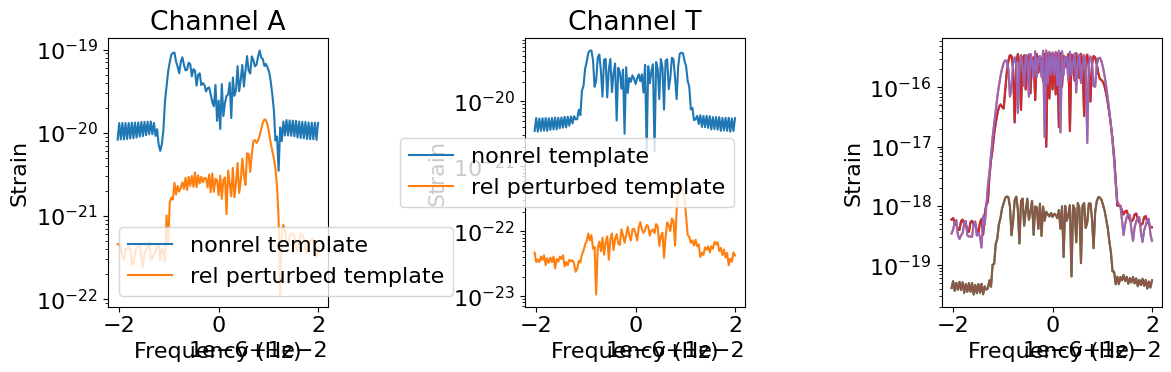

In [33]:
plt.figure(figsize=(12, 4))
for template_generator, backend_name, label in zip(list_templates, list_backend_names, labels):
    if label == "rel template":
        # skip the perturbed template for the mismatch check, as it is not a good template
        continue
    # plot injection and template for sanity check
    A_temp, E_temp, T_temp = template_generator.get_tdi(jnp.array(injection_source_params), tdi_generation=2.0, tdi_combination="AET")
    
    plt.subplot(1, 3, 1)
    plt.title(f"Channel A")
    plt.semilogy(freqs, np.abs(d_inj[0]-A_temp), label=label)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    plt.legend()
    plt.subplot(1, 3, 2)
    plt.title(f"Channel T")
    plt.semilogy(freqs, np.abs(d_inj[2]-T_temp), label=label)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    plt.legend()
    plt.subplot(1, 3, 3)
    for ch in range(3):
        plt.semilogy(freqs, np.abs(d_inj[ch]), label=label + f" {['A','E','T'][ch]} channel")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    plt.tight_layout()
    
    ################################# Mismatch check at true params ##########################################################
    print("\n" + "=" * 60)
    A_check, E_check, T_check = template_generator.get_tdi(jnp.array(injection_source_params), tdi_generation=2.0, tdi_combination="AET")
    d_check = np.stack([A_check, E_check, T_check], axis=0)
    print("Mismatch:", float(template_generator.mismatch(d_check[None], d_inj[None], inv_cov_AET)[0]))
    ll_inj  = likelihood(jnp.atleast_2d(injection_source_params), rel_nominal_orbit,   inv_cov_AET, temp_params)
    ll_nonrel = likelihood(jnp.atleast_2d(injection_source_params), template_generator, inv_cov_AET, temp_params)
    print(f"Loglike (rel template, true params):   {ll_inj}")
    print(f"Loglike ({label}, true params): {ll_nonrel}")

plt.show()

# Differential evolution

/opt/miniconda3/envs/lisa_resp/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:518: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,



nonrel template best-fit parameters: [1.00000000e-02 9.62964972e-35 1.00000000e-22 0.00000000e+00
 0.00000000e+00 1.04719755e+00 1.04719755e+00 1.04719755e+00]
Relative difference in parameters: [ 0.00000000e+00             inf  0.00000000e+00             nan
             nan -2.12036979e-16  0.00000000e+00 -2.12036979e-16]
nonrel template best-fit log-likelihood: -0.0005326662105446824

Mismatch: 8.160824904734909e-08


/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_90400/3848882204.py:22: RuntimeWarning: divide by zero encountered in divide
  print(f"Relative difference in parameters: {(best_fit_params - injection_source_params) / injection_source_params}")
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_90400/3848882204.py:22: RuntimeWarning: invalid value encountered in divide
  print(f"Relative difference in parameters: {(best_fit_params - injection_source_params) / injection_source_params}")


Loglike (rel template, true params):   [-1.31979744e-28]
Loglike (nonrel template, true params): [-0.00053267]


/opt/miniconda3/envs/lisa_resp/lib/python3.12/site-packages/scipy/optimize/_differentialevolution.py:518: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,



rel perturbed template best-fit parameters: [1.00000000e-02 9.62964972e-35 1.00000000e-22 0.00000000e+00
 0.00000000e+00 1.04719755e+00 1.04719755e+00 1.04719755e+00]
Relative difference in parameters: [ 0.00000000e+00             inf  0.00000000e+00             nan
             nan -2.12036979e-16  0.00000000e+00 -2.12036979e-16]
rel perturbed template best-fit log-likelihood: -1.084454634229936e-06

Mismatch: 1.6382939449499645e-10
Loglike (rel template, true params):   [-1.31979744e-28]
Loglike (rel perturbed template, true params): [-1.08445463e-06]


/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_90400/3848882204.py:22: RuntimeWarning: divide by zero encountered in divide
  print(f"Relative difference in parameters: {(best_fit_params - injection_source_params) / injection_source_params}")
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_90400/3848882204.py:22: RuntimeWarning: invalid value encountered in divide
  print(f"Relative difference in parameters: {(best_fit_params - injection_source_params) / injection_source_params}")


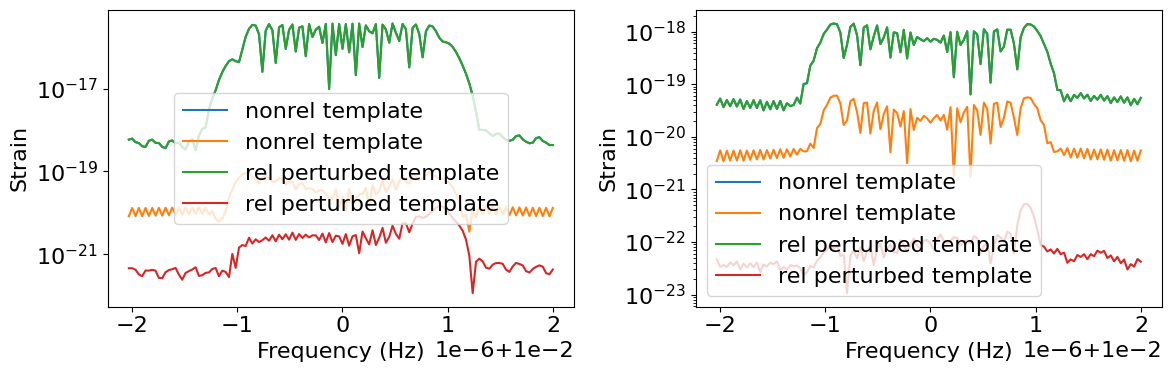

In [35]:
from scipy.optimize import differential_evolution

def neg_ll(params, template_generator, inv_cov, temp_params):
    out = likelihood(params.T, template_generator, inv_cov, temp_params)
    # print(f"Params: {params}, Loglike: {out}")
    return -out

plt.figure(figsize=(12, 4))

for template_generator, backend_name, label in zip(list_templates, list_backend_names, labels):
    if label == "rel template":
        # skip the perturbed template for the mismatch check, as it is not a good template
        continue
    ll_nonrel = likelihood(jnp.atleast_2d(injection_source_params), template_generator, inv_cov_AET, temp_params)
    out = differential_evolution(neg_ll, args=(template_generator, inv_cov_AET, temp_params),
                                 popsize=32,
                                 x0=injection_source_params, vectorized=True, polish=False,
                                 bounds=bounds, maxiter=100, disp=False)
    best_fit_params = out.x
    best_fit_ll = -out.fun
    # print(f"\n{label} best-fit parameters: {best_fit_params}")
    print(f"Relative difference in parameters: {(best_fit_params - injection_source_params) / injection_source_params}")
    print(f"{label} best-fit log-likelihood: {best_fit_ll}")
    A_temp, E_temp, T_temp = template_generator.get_tdi(jnp.array(best_fit_params), tdi_generation=2.0, tdi_combination="AET")
    
    plt.subplot(1, 2, 1)
    plt.semilogy(freqs, np.abs(d_inj[0]), label=label)
    plt.semilogy(freqs, np.abs(d_inj[0]-A_temp), label=label)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.semilogy(freqs, np.abs(d_inj[2]), label=label)
    plt.semilogy(freqs, np.abs(d_inj[2]-T_temp), label=label)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Strain")
    plt.legend()
    plt.tight_layout()
    
    print("\n" + "=" * 60)
    A_check, E_check, T_check = A_temp, E_temp, T_temp
    d_check = np.stack([A_check, E_check, T_check], axis=0)
    print("Mismatch:", float(template_generator.mismatch(d_check[None], d_inj[None], inv_cov_AET)[0]))
    ll_inj  = likelihood(jnp.atleast_2d(injection_source_params), rel_nominal_orbit,   inv_cov_AET, temp_params)
    ll_nonrel = likelihood(jnp.atleast_2d(injection_source_params), template_generator, inv_cov_AET, temp_params)
    print(f"Loglike (rel template, true params):   {ll_inj}")
    print(f"Loglike ({label}, true params): {ll_nonrel}")


plt.show()